# Water Quality Classification Project

In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## Exploratory Data Analysis

In [110]:
water_data = pd.read_csv('SAFER_RA_cleaned.csv')

# List of columns to include
include_cols = ['TINWSYS_IS_NUMBER', 'CURRENT_FAILING', 'SERVICE_CONNECTIONS', 'POPULATION', 
                'OWNER_TYPE', 'FEDERAL_CLASSIFICATION_TYPE', 'MHI', 'CALENVIRO_SCREEN_SCORE', 
                'REGIONAL_BOARD', 'FUNDING_RECEIVED_SINCE_2017', 
                'TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017'
                ]

water_data_include = water_data[include_cols]

# Check for missing values
water_data_include.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   TINWSYS_IS_NUMBER                        3204 non-null   int64  
 1   CURRENT_FAILING                          3204 non-null   object 
 2   SERVICE_CONNECTIONS                      3204 non-null   int64  
 3   POPULATION                               3204 non-null   int64  
 4   OWNER_TYPE                               3204 non-null   object 
 5   FEDERAL_CLASSIFICATION_TYPE              3204 non-null   object 
 6   MHI                                      3189 non-null   float64
 7   CALENVIRO_SCREEN_SCORE                   3168 non-null   float64
 8   REGIONAL_BOARD                           3161 non-null   object 
 9   FUNDING_RECEIVED_SINCE_2017              3204 non-null   float64
 10  TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017  3204 no

In [111]:
# Drop missing values
water_data_clean = water_data_include.dropna()

<Axes: >

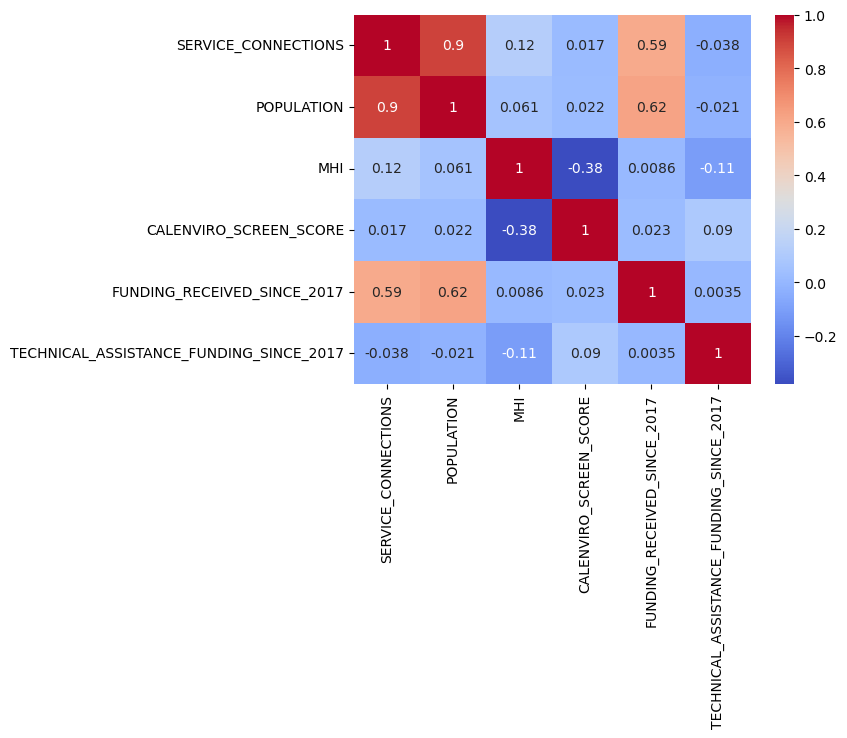

In [ ]:
# Identify multicolinearity between continuous variables
water_cont = water_data_clean[['SERVICE_CONNECTIONS', 'POPULATION', 'MHI', 
                           'CALENVIRO_SCREEN_SCORE', 'FUNDING_RECEIVED_SINCE_2017', 
                           'TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017']]

# Heat map
sns.heatmap(water_cont.corr(), annot=True, cmap='coolwarm')



Since SERVICE_CONNECTIONS and POPULATION are strongly correlated, we dropped SERVICE_CONNECTIONS from our predictors.

## Preprocessing

<Axes: ylabel='TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017'>

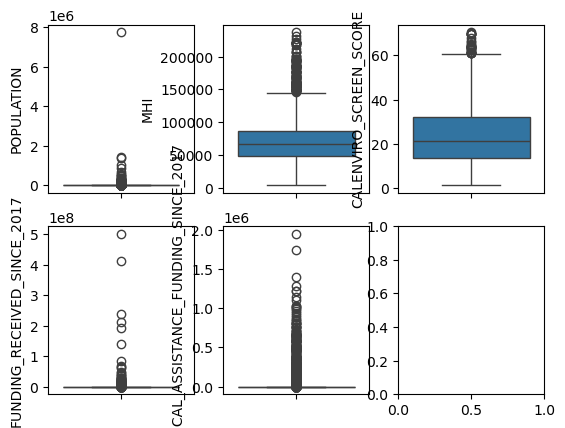

In [113]:
# Plot distributions
fig, axs =  plt.subplots(2,3)
sns.boxplot(water_cont.POPULATION,ax=axs[0,0])
sns.boxplot(water_cont.MHI,ax=axs[0,1])
sns.boxplot(water_cont.CALENVIRO_SCREEN_SCORE,ax=axs[0,2])
sns.boxplot(water_cont.FUNDING_RECEIVED_SINCE_2017,ax=axs[1,0])
sns.boxplot(water_cont.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017,ax=axs[1,1])

The boxplots show that the distributions of all the continuous predictors are extremely right-skewed and on different scales. We will log-transform the data to reduce the right skew and then standardize it to fix the scale differences.

In [122]:
# Log transform
water_cont_log = water_cont.copy()
water_cont_log.POPULATION = np.log(water_cont.POPULATION + 0.1)
water_cont_log.FUNDING_RECEIVED_SINCE_2017 = np.log(
    water_cont.FUNDING_RECEIVED_SINCE_2017 + 0.1)
water_cont_log.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017 = np.log(
    water_cont.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017 + 0.1)

# Standardize
scaler = StandardScaler()
water_cont_scaled = scaler.fit_transform(water_cont_log)

water_cont_scaled = pd.DataFrame(
    scaler.fit_transform(water_cont_log),
    columns=water_cont.columns,
    index=water_cont.index)

<Axes: ylabel='TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017'>

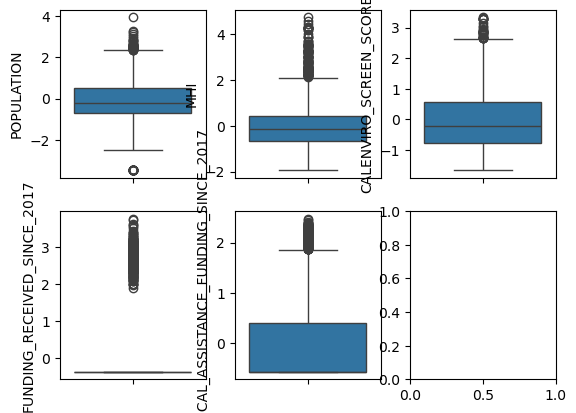

In [ ]:
# Plot new distributions
# FIX LABELS
fig, axs =  plt.subplots(2,3)
sns.boxplot(water_cont_scaled.POPULATION,ax=axs[0,0])
sns.boxplot(water_cont_scaled.MHI,ax=axs[0,1])
sns.boxplot(water_cont_scaled.CALENVIRO_SCREEN_SCORE,ax=axs[0,2])
sns.boxplot(water_cont_scaled.FUNDING_RECEIVED_SINCE_2017,ax=axs[1,0])
sns.boxplot(water_cont_scaled.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017,ax=axs[1,1])

In [135]:
# One-hot encode regional board, owner type, federal classification, and current failing
water_one_hot = pd.get_dummies(water_data_clean, 
                               columns=['CURRENT_FAILING', 'REGIONAL_BOARD', 'OWNER_TYPE', 
                                        'FEDERAL_CLASSIFICATION_TYPE'], 
                                        dtype=int)



water_one_hot.columns = ['ID','SERVICE_CONNECTIONS','POPULATION','MHI','CALENVIRO_SCREEN_SCORE',
                         'FUNDING__SINCE_2017','TECH_FUNDING_SINCE_2017','CURRENT_FAILING',
                         'CURRENT_NOT_FAILING','REGIONAL_BOARD_1','REGIONAL_BOARD_2',
                         'REGIONAL_BOARD_3','REGIONAL_BOARD_4','REGIONAL_BOARD_5_FRESNO',
                         'REGIONAL_BOARD_5_REDDING','REGIONAL_BOARD_5_SACRAMENTO',
                         'REGIONAL_BOARD_6_TAHOE','REGIONAL_BOARD_6_VICTORVILLE',
                         'REGIONAL_BOARD_7','REGIONAL_BOARD_8','REGIONAL_BOARD_9',
                         'FEDERAL_GOVERNMENT_OWNED','LOCAL_OWNED','MIXED_OWNED','PRIVATE_OWNED',
                         'STATE_GOVERNMENT_OWNED','FEDERAL_CLASS_COMMUNITY',
                         'FEDERAL_CLASS_NON-TRANSIENT_NON-COMMUNITY',
                         'FEDERAL_CLASS_TRANSIENT_NON-COMMUNITY']

In [136]:
water_one_hot

,ID,SERVICE_CONNECTIONS,POPULATION,MHI,CALENVIRO_SCREEN_SCORE,FUNDING__SINCE_2017,TECH_FUNDING_SINCE_2017,CURRENT_FAILING,CURRENT_NOT_FAILING,REGIONAL_BOARD_1,...,REGIONAL_BOARD_8,REGIONAL_BOARD_9,FEDERAL_GOVERNMENT_OWNED,LOCAL_OWNED,MIXED_OWNED,PRIVATE_OWNED,STATE_GOVERNMENT_OWNED,FEDERAL_CLASS_COMMUNITY,FEDERAL_CLASS_NON-TRANSIENT_NON-COMMUNITY,FEDERAL_CLASS_TRANSIENT_NON-COMMUNITY
0,3,19,50,130464.0,13.969586,0.0,0.00,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,4,191,459,61897.0,31.384971,0.0,0.00,0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,18,207,524,178706.0,10.074452,3000000.0,830.93,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,19,1,50,140487.0,16.381997,274408.0,0.00,0,1,0,...,0,0,0,1,0,0,0,0,1,0
4,29,86959,344000,157713.0,21.844306,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199,6226,4434,16595,80115.0,28.036047,0.0,169681.22,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3200,6227,1270,4124,74287.0,21.614898,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3201,6228,43,122,63664.0,30.214329,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3202,6229,795,2772,32000.0,12.323297,443426.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0


In [ ]:
# Combine preprocessed categorical and continuous data
water_cat = water_one_hot.drop(['SERVICE_CONNECTIONS','POPULATION',
                                'MHI','CALENVIRO_SCREEN_SCORE',
                                'FUNDING__SINCE_2017',
                                'TECH_FUNDING_SINCE_2017'], axis=1)

# Final cleaned and pre-processed data
water_processed = pd.concat([water_cat, water_cont_scaled], axis=1)